# Proyek Machine Learning : Klasifikasi Pengangguran Indonesia
- **Nama:** Muhammad Firza Fernanda

## Menentukan Pertanyaan Bisnis
- 1. Apa dan berapa jenjang terakhir pendidikan yang ditempuh oleh para penganggur di Indonesia?
- 2. Pada tahun berapa angka tinggi pengangguran di Indonesia?

## Import Semua Packages/Library yang Digunakan

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import csv
import streamlit as st
from datetime import datetime, timedelta


### Gathering Data

Dataset dibaca menggunakan Pandas dan menampilkan isinya untuk memastikan data telah dimuat. Hal tersebut dilakukan guna pengeceka struktur dan kelengkapan data untuk memastikan dataset siap digunakan dalam analisis.

In [2]:
#memasukkan dan menampilkan dataset
df = pd.read_csv('dataset/Data Training-1.csv')
df

,Periode,Bulan,Tidak/belum pernah sekolah,Tidak/belum tamat SD,SD,SLTP,SLTA Umum/SMU,SLTA Kejuruan/SMK,Akademi/Diploma,Universitas,Total
0,2006,Februari,234465,614960,2675459,2860007,2842876,1204140,297185,375601,11104693
1,2006,Agustus,170666,611254,2589699,2730045,2851518,1305190,278074,395554,10932000
2,2007,Februari,145750,520316,2753548,2643062,2630360,1114675,330316,409890,10547917
3,2007,Agustus,94301,438519,2179792,2264198,2532204,1538349,397191,566588,10011142
4,2008,Februari,79764,448431,2216748,2166619,2204377,1165582,519867,626202,9427590
5,2008,Agustus,103206,443832,2099968,1973986,2403394,1409128,362683,598318,9394515
6,2009,Februari,60347,415955,2143747,2054682,2133627,1337586,486399,626621,9258964
7,2009,Agustus,90471,547430,1531671,1770823,2472245,1407226,441100,701651,8962617
8,2010,Februari,59066,547164,1522465,1657452,2111256,1336881,538186,820020,8592490
9,2010,Agustus,157586,600221,1402858,1661449,2149123,1195192,443222,710128,8319779


 **Insight:**

Pada dataset yang didapatkan, kita bisa mendapatkan insight untuk dapat menjawab pertanyaan bisnis yang dibuat
1. Pertanyaan pertama akan menggunakan 8 kolom jenjang terakhir pendidikan (tidak/belum pernah sekolah, tidak/belum tamat SD, SLTP, SLTA Umum/SMU, SLTA Kejuruan/SMK, Akademisi/Diploma, Universitas) sebagai penganalisiaan jumlah penganggur yang telah menjenjang pendidikan terakhirnya. Pada semua kolom tersebut menggunakan integer.
2. Pertanyaan kedua akan menggunankan kolom Periode dan kolom Total guna penganalisaan terhadap angka pengangguran tertinggi pada tahun apa.

### Assessing Data

Memeriksa jumlah nilai kosong di setiap kolom untuk memastikan data siap digunakan.

In [3]:
df.isnull().sum()

Periode                       0
Bulan                         0
Tidak/belum pernah sekolah    0
Tidak/belum tamat SD          0
SD                            0
SLTP                          0
SLTA Umum/SMU                 0
SLTA Kejuruan/SMK             0
Akademi/Diploma               0
Universitas                   0
Total                         0
dtype: int64

In [4]:
df.duplicated().sum()

np.int64(1)

In [5]:
df.describe(include='all')

,Periode,Bulan,Tidak/belum pernah sekolah,Tidak/belum tamat SD,SD,SLTP,SLTA Umum/SMU,SLTA Kejuruan/SMK,Akademi/Diploma,Universitas,Total
count,35.000000,35,35.000000,35.000000,3.500000e+01,3.500000e+01,3.500000e+01,3.500000e+01,35.000000,35.000000,3.500000e+01
unique,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,Agustus,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,18,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,2014.228571,NaN,83398.457143,496154.714286,1.462738e+06,1.697168e+06,2.153685e+06,1.422718e+06,290182.771429,642869.171429,8.247912e+06
std,5.082182,NaN,53949.291460,105794.400661,5.112940e+05,4.367373e+05,3.518458e+05,3.361657e+05,103575.191557,167112.979108,1.233931e+06
min,2006.000000,NaN,15206.000000,328781.000000,8.657780e+05,1.137195e+06,1.546699e+06,8.473650e+05,159490.000000,375601.000000,6.898796e+06
25%,2010.000000,NaN,38596.500000,422384.000000,1.219224e+06,1.343867e+06,1.902169e+06,1.184779e+06,219345.000000,548211.000000,7.125746e+06
50%,2014.000000,NaN,79764.000000,489152.000000,1.320392e+06,1.650387e+06,2.133627e+06,1.383022e+06,254457.000000,626621.000000,8.319779e+06
75%,2018.500000,NaN,107820.500000,579941.000000,1.487256e+06,1.828030e+06,2.437820e+06,1.595546e+06,317788.500000,743362.000000,9.032334e+06


In [6]:
# Exploratory Data Analysis (EDA)
mean_by_belum_sekolah = df['Tidak/belum pernah sekolah'].mean()
mean_by_belum_sd = df['Tidak/belum tamat SD'].mean()
mean_by_sd = df['SD'].mean()
mean_by_smp = df['SLTP'].mean()

mean_by_sma = df['SLTA Umum/SMU'].mean()
mean_by_smk = df['SLTA Kejuruan/SMK'].mean()

mean_by_diploma = df['Akademi/Diploma'].mean()
mean_by_sarjana = df['Universitas'].mean()


In [7]:
mean_education_df = pd.DataFrame({
    "Tingkat Pendidikan": [
        "Tidak/belum pernah sekolah",
        "Tidak/belum tamat SD",
        "SD",
        "SMP",
        "SMA",
        "SMK",
        "Akademi/Diploma",
        "Universitas"
    ],
    "Rata-rata Jumlah Penduduk": [
        mean_by_belum_sekolah,
        mean_by_belum_sd,
        mean_by_sd,
        mean_by_smp,
        mean_by_sma,
        mean_by_smk,
        mean_by_diploma,
        mean_by_sarjana
    ]
})

mean_education_df

,Tingkat Pendidikan,Rata-rata Jumlah Penduduk
0,Tidak/belum pernah sekolah,8.339846e+04
1,Tidak/belum tamat SD,4.961547e+05
2,SD,1.462738e+06
3,SMP,1.697168e+06
4,SMA,2.153685e+06
5,SMK,1.422718e+06
6,Akademi/Diploma,2.901828e+05
7,Universitas,6.428692e+05


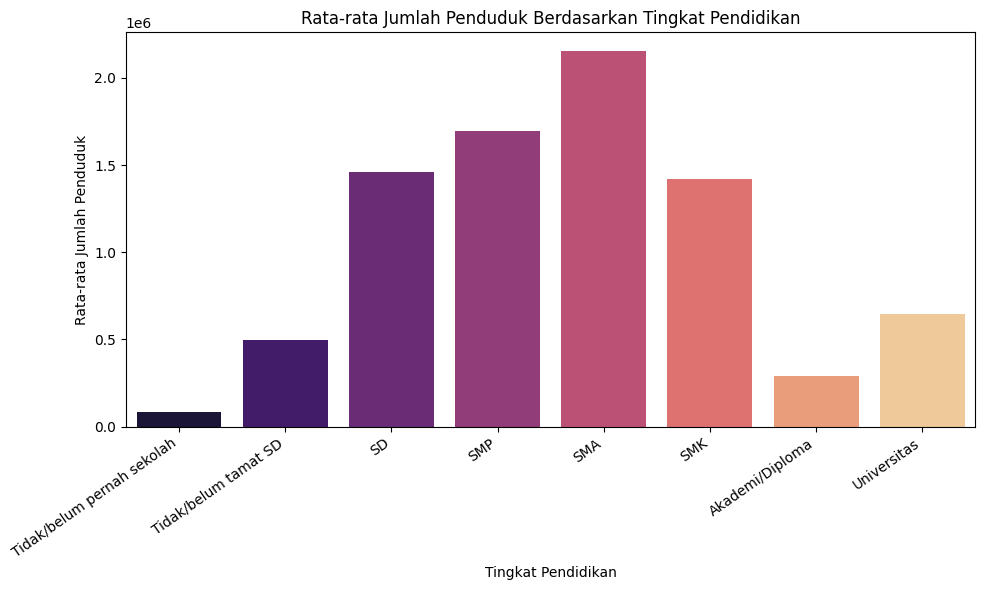

In [8]:

plt.figure(figsize=(10, 6))
sns.barplot(data=mean_education_df,
    x="Tingkat Pendidikan",
    hue="Tingkat Pendidikan",
    y="Rata-rata Jumlah Penduduk",
    palette="magma"
)
plt.xticks(rotation=35, ha="right")
plt.title("Rata-rata Jumlah Penduduk Berdasarkan Tingkat Pendidikan")
plt.ylabel("Rata-rata Jumlah Penduduk")
plt.tight_layout()
plt.show()

In [9]:
df.groupby('Periode')['Total'].mean().sort_values()

Periode
2019     7001610.0
2017     7005262.0
2018     7018421.0
2016     7027973.5
2014     7195987.0
2013     7325914.0
2015     7507794.5
2012     7551348.5
2020     8346620.0
2022     8418005.0
2010     8456134.5
2011     8530637.0
2021     8924030.0
2009     9110790.5
2008     9411052.5
2007    10279529.5
2006    11018346.5
Name: Total, dtype: float64

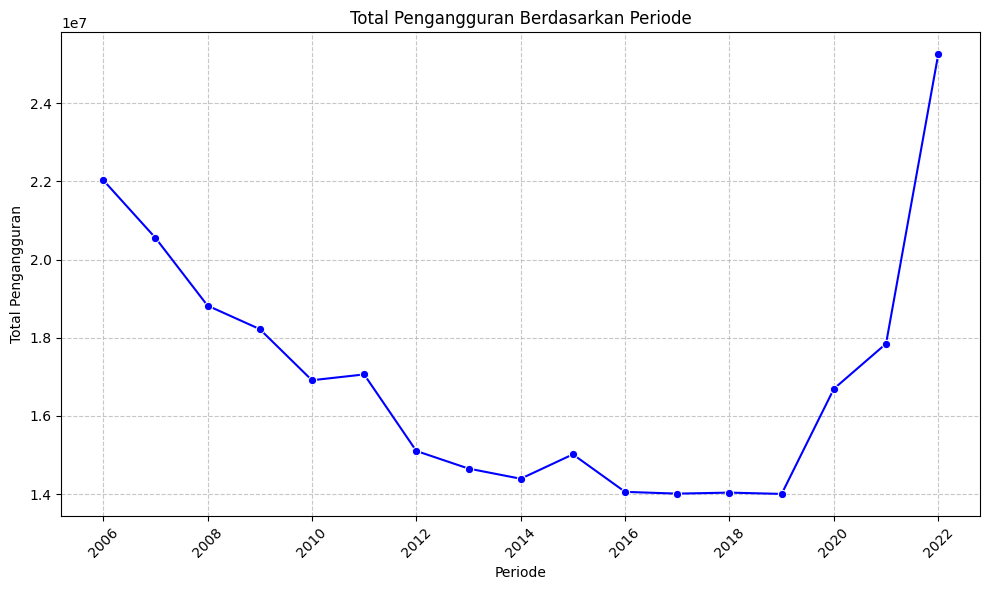

In [10]:
total_pengangguran_per_tahun = df.groupby('Periode')['Total'].sum().sort_index()

plt.figure(figsize=(10, 6))
sns.lineplot(x=total_pengangguran_per_tahun.index.astype(int), 
             y=total_pengangguran_per_tahun.values, 
             marker='o', color='blue')
plt.xlabel("Periode")
plt.ylabel("Total Pengangguran")
plt.title("Total Pengangguran Berdasarkan Periode")
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()